**Description Of the features of the dataset:**

Y – Latitude coordinate of the observation station.
X – Longitude coordinate of the observation station.
data_payload_id – Unique identifier for the data record.
instance_datetime – Timestamp when the data was recorded.
url – URL reference to the data source.
agency – Organization responsible for the data.
platform_type – Type of platform (e.g., station, balloon, etc.).
platform_id – Numeric ID for the platform.
platform_name – Name of the observation platform or station.
gaw_id – Global Atmosphere Watch ID of the platform.
instrument_name – Name of the instrument used for measurement.
instrument_model – Model of the instrument.
instrument_number – Instrument's identification number.
monthly_date – Date associated with monthly aggregated data.
monthly_columno3 – Monthly average ozone column value.
monthly_stddevo3 – Standard deviation of the monthly ozone values.
monthly_npts – Number of observations used in monthly average.
daily_date – Date of the daily observation.
daily_wlcode – Wavelength code used during observation.
daily_obscode – Observation code (e.g., method or technique).
daily_columno3 – Daily ozone column measurement (Dobson Units).
daily_stddevo3 – Standard deviation of the daily ozone value.
daily_utc_begin – UTC time when observation began.
daily_utc_end – UTC time when observation ended.
daily_utc_mean – Mean UTC time of observation.
daily_nobs – Number of observations for that day.
daily_mmu – Measurement uncertainty for daily ozone.
daily_columnso2 – Daily SO₂ (sulfur dioxide) column measurement.
latest_observation – Flag indicating if this is the most recent data (0 or 1).
country – Country of the observation station.
scientific_authority – Name of the responsible scientist or authority.
version – Version number of the data record.

**Combining  8 Countries Datasets**
<br>
<ol>
<li>Argentina</li>
<li>Brazil</li>
<li>Canada</li>
<li>Chile</li>
<li>Greenland</li>
<li>Mexico</li>
<li>Peru</li>
<li>USA</li>
</ol>

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import optuna
from optuna.samplers import TPESampler
import plotly.express as px
import plotly.graph_objects as go


**Visualization**

In [33]:
df1=pd.read_csv('combined_dataset/totalozone_ARG.csv')
df2=pd.read_csv('combined_dataset/totalozone_BRA.csv')
df3=pd.read_csv('combined_dataset/totalozone_CAN.csv')
df4=pd.read_csv('combined_dataset/totalozone_CHL.csv')
df5=pd.read_csv('combined_dataset/totalozone_GRL.csv')
df6=pd.read_csv('combined_dataset/totalozone_MEX.csv')
df7=pd.read_csv('combined_dataset/totalozone_PER.csv')
df8=pd.read_csv('combined_dataset/totalozone_USA.csv')
df=pd.concat([df1, df2, df3, df4, df5, df6, df7, df8], ignore_index=True)
df['daily_date'] = pd.to_datetime(df['daily_date'], format='%Y-%m-%d')
df.head()


c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (21,26) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (22,25,26,27) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns

,x,y,identifier,file_path,dataset_id,station_id,station_name,station_gaw_id,station_gaw_url,contributor_name,...,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,monthly_date,monthly_columno3,monthly_stdevo3,monthly_npts,url
0,-58.480,-34.580,Dobson:Beck:70:TotalOzone_1.0:091:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,91,Buenos Aires Observatorio,BSO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,6.0,1.800,NaN,2025-04-30T00:00:00Z,277.2,13.9,29.0,https://woudc.org/archive/Archive-NewFormat/To...
1,-68.310,-54.850,Dobson:Beck:131:TotalOzone_1.0:339:SMNA:WOUDC:...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,339,Ushuaia,USH,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,17.5,17.5,1.0,2.976,NaN,2025-04-30T00:00:00Z,277.0,27.7,30.0,https://woudc.org/archive/Archive-NewFormat/To...
2,-67.500,-45.783,Dobson:Beck:133:TotalOzone_1.0:342:SMNA:WOUDC:...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,342,Comodoro Rivadavia Aero,CMR,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,16.0,NaN,8.0,2.300,NaN,2025-04-30T00:00:00Z,263.4,21.7,28.0,https://woudc.org/archive/Archive-NewFormat/To...
3,-65.438,-22.111,Dobson:Beck:97:TotalOzone_1.0:513:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,513,La Quiaca,LQO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,3.0,1.500,NaN,2025-04-30T00:00:00Z,254.1,3.5,25.0,https://woudc.org/archive/Archive-NewFormat/To...
4,-58.480,-34.580,Dobson:Beck:70:TotalOzone_1.0:091:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,91,Buenos Aires Observatorio,BSO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,6.0,1.700,NaN,2025-04-30T00:00:00Z,277.2,13.9,29.0,https://woudc.org/archive/Archive-NewFormat/To...


**Area Chart of Year Vs Ozone**

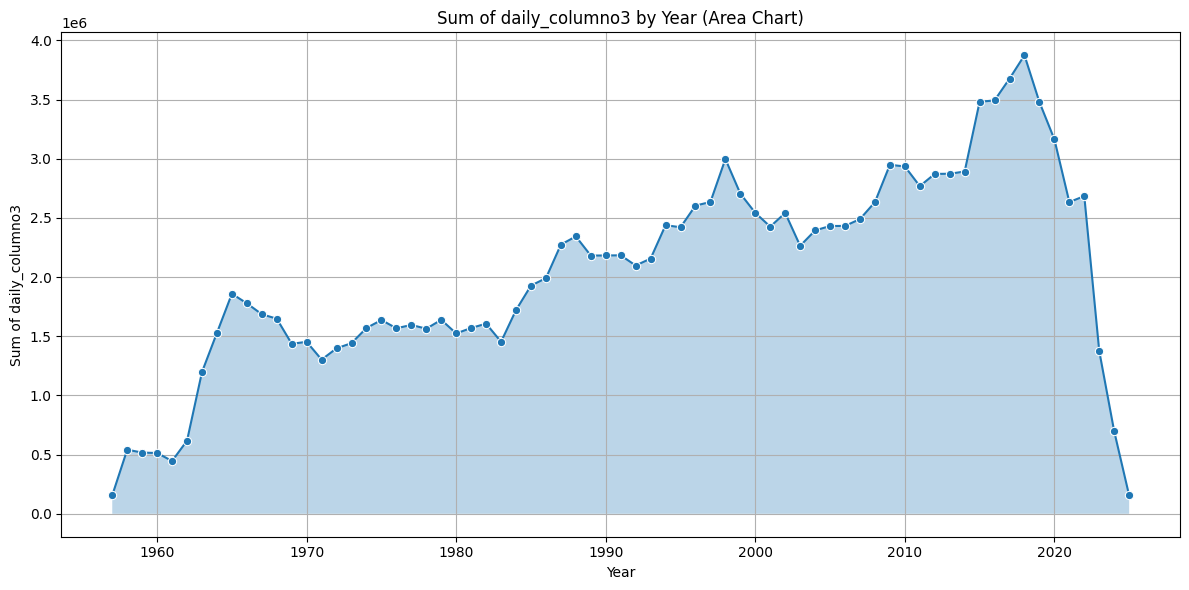

In [40]:
df['year'] = pd.to_numeric(df['year'])

plt.figure(figsize=(12, 6))
df_yearly = df.groupby('year')['daily_columno3'].sum().reset_index()
sns.lineplot(data=df_yearly, x='year', y='daily_columno3', marker='o')
plt.fill_between(df_yearly['year'], df_yearly['daily_columno3'], alpha=0.3)
plt.title('Sum of daily_columno3 by Year (Area Chart)')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()


**Bar Chart of Year Vs Ozone (After and Before 1989)**

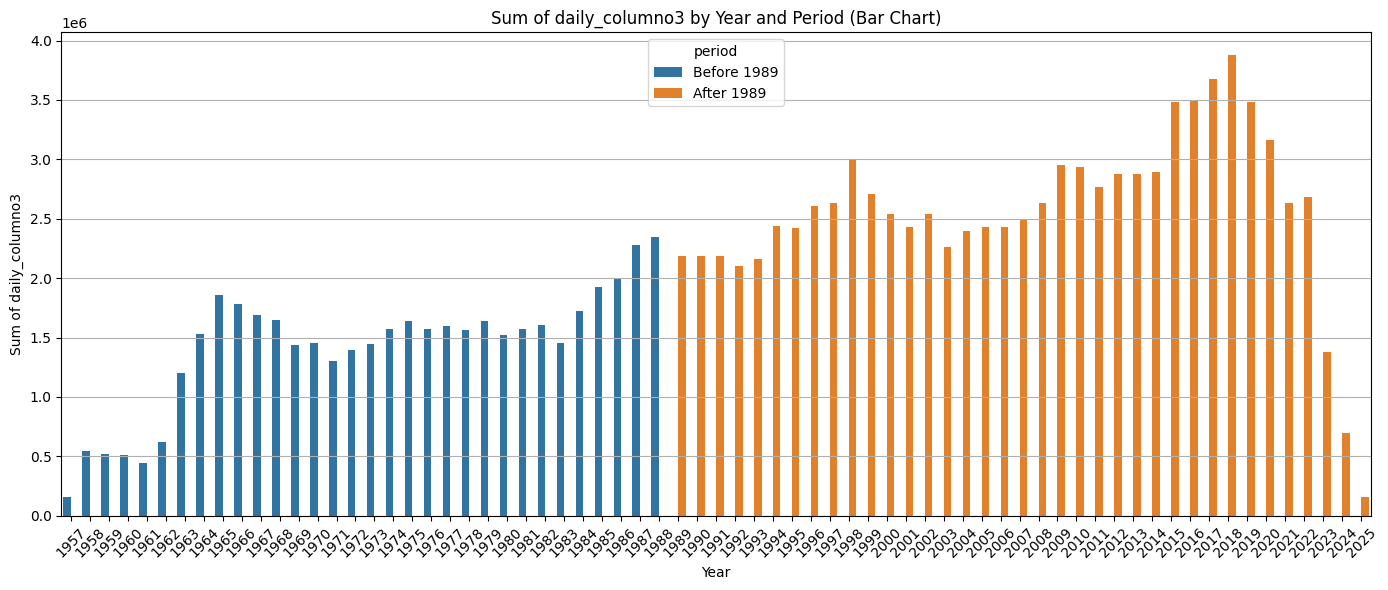

In [45]:
df['period'] = df['year'].apply(lambda x: 'Before 1989' if x < 1989 else 'After 1989')

# Group by year and period
df_period = df.groupby(['year', 'period'])['daily_columno3'].sum().reset_index()

# Plot bar chart
plt.figure(figsize=(14, 6))
sns.barplot(data=df_period, x='year', y='daily_columno3', hue='period', dodge=True)

plt.title('Sum of daily_columno3 by Year and Period (Bar Chart)')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

**Bar Chart of Year Vs Ozone**

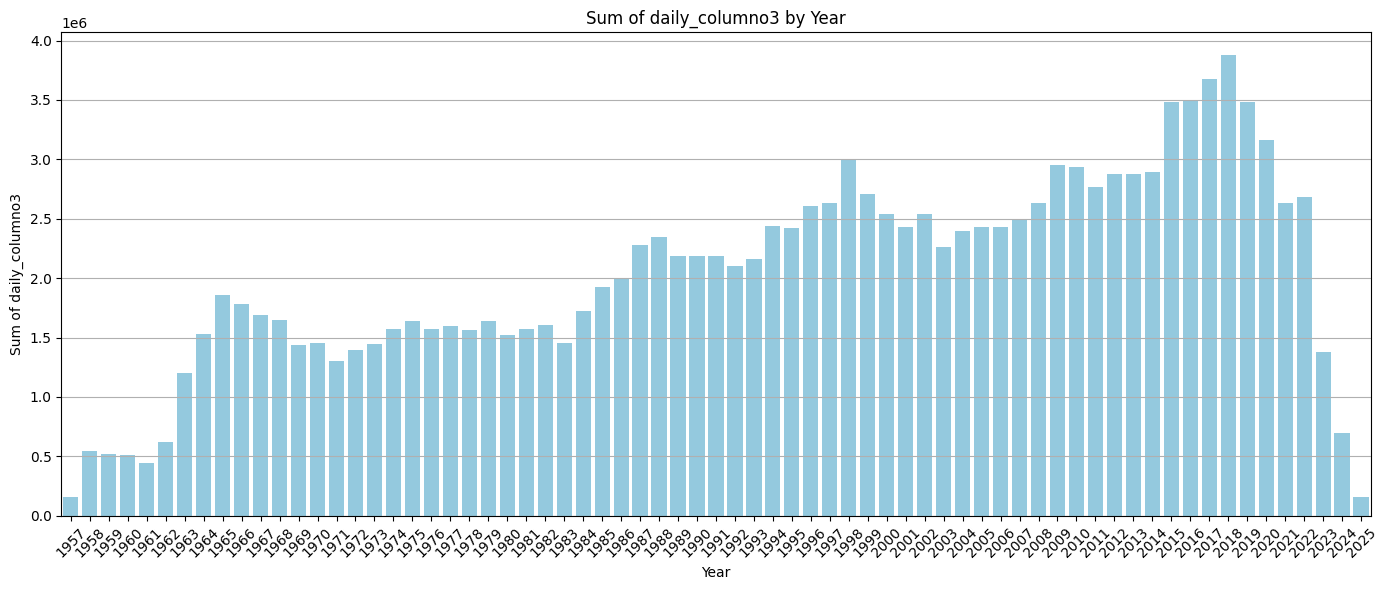

In [46]:
df_yearly = df.groupby('year')['daily_columno3'].sum().reset_index()

# Plot bar chart
plt.figure(figsize=(14, 6))
sns.barplot(data=df_yearly, x='year', y='daily_columno3', color='skyblue')

plt.title('Sum of daily_columno3 by Year')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

**Line chart Year vs ozone (before and after 1989)**

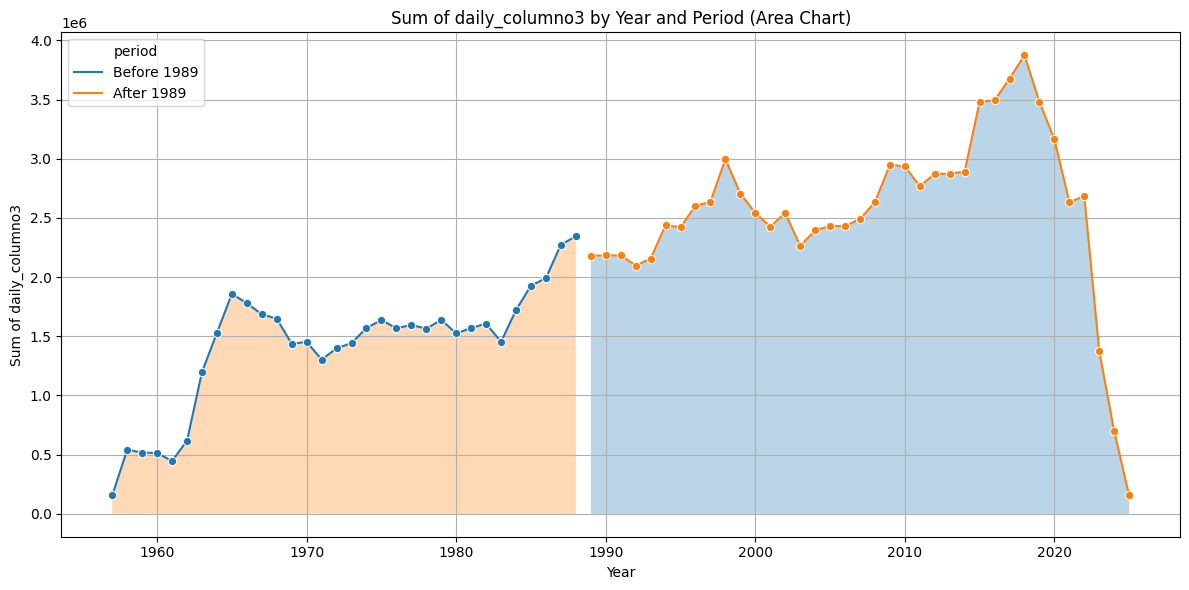

In [41]:
df['period'] = df['year'].apply(lambda x: 'Before 1989' if x < 1989 else 'After 1989')
plt.figure(figsize=(12, 6))
df_period = df.groupby(['year', 'period'])['daily_columno3'].sum().reset_index()
sns.lineplot(data=df_period, x='year', y='daily_columno3', hue='period', marker='o')
for period, group in df_period.groupby('period'):
    plt.fill_between(group['year'], group['daily_columno3'], alpha=0.3, label=f"{period} (area)")
plt.title('Sum of daily_columno3 by Year and Period (Area Chart)')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()


**Country wise year vs ozone**

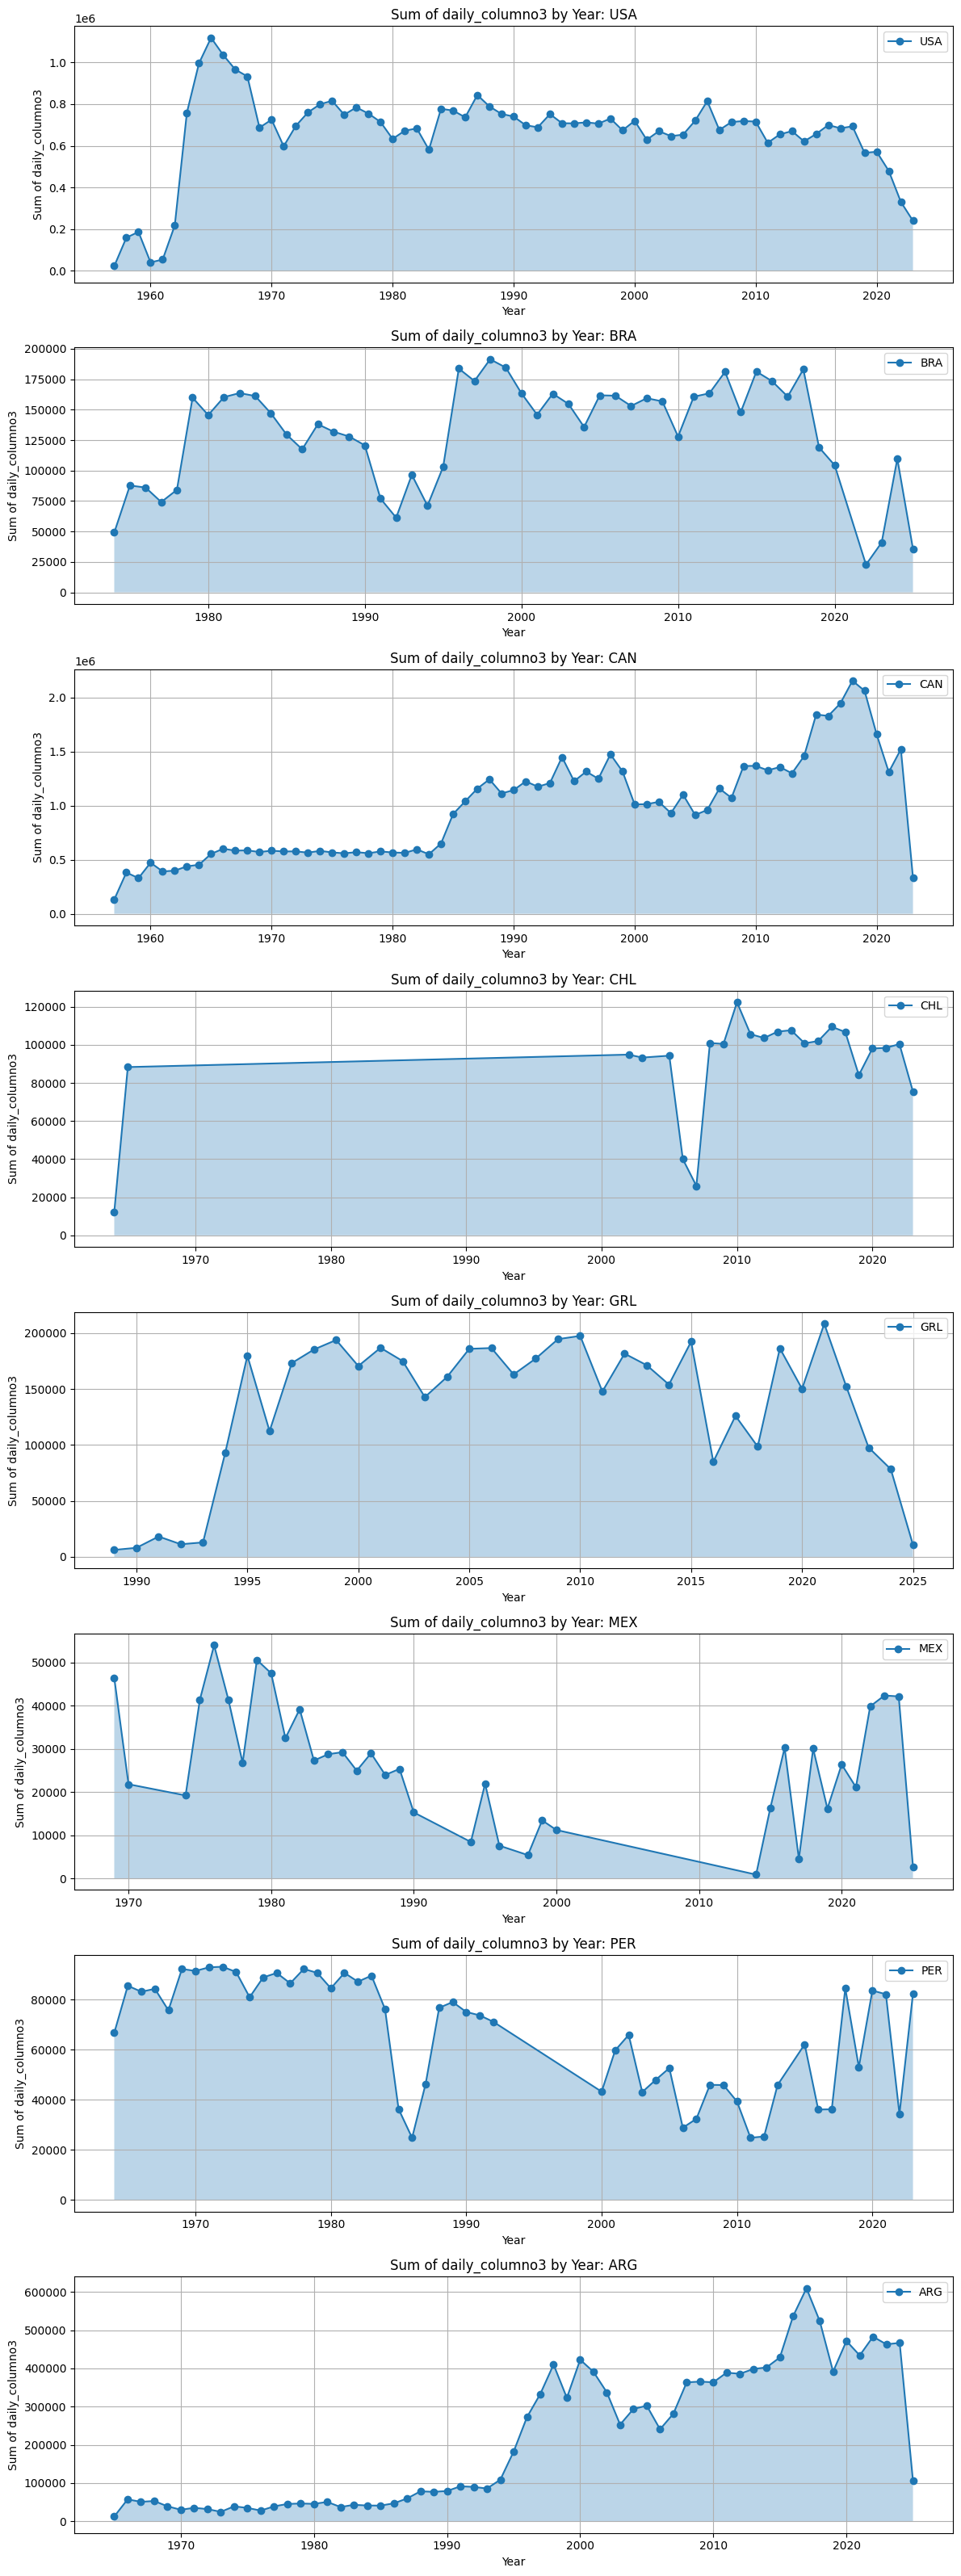

In [42]:
countries = ['USA', 'BRA', 'CAN', 'CHL', 'GRL', 'MEX', 'PER','ARG']

plt.figure(figsize=(12,4 * len(countries)))
for idx, country in enumerate(countries, 1):
    plt.subplot(len(countries), 1, idx)
    df_country = df[df['country_id'] == country]
    df_yearly = df_country.groupby('year')['daily_columno3'].sum().reset_index()
    plt.plot(df_yearly['year'], df_yearly['daily_columno3'], marker='o', label=country)
    plt.fill_between(df_yearly['year'], df_yearly['daily_columno3'], alpha=0.3)
    plt.title(f'Sum of daily_columno3 by Year: {country}')
    plt.ylabel('Sum of daily_columno3')
    plt.xlabel('Year')
    plt.grid(True)
    plt.legend()
plt.tight_layout()
plt.show()


**Pre-Processing**

**Droping Other Unnecessary Columns**

In [6]:
columns = [
    'x',
    'y',
    'identifier',
    'file_path',
    'dataset_id',
    'station_id',
    'station_name',
    'station_gaw_id',
    'station_gaw_url',
    'contributor_name',
    'contributor_id',
    'contributor_url',
    'country_id',
    'country_name_en',
    'country_name_fr',
    'gaw_id',
    'instrument_name',
    'instrument_model',
    'instrument_serial',
    'observation_date',
    'daily_wlcode',
    'daily_obscode',
    'daily_stdevo3',
    'daily_utc_begin',
    'daily_utc_end',
    'daily_utc_mean',
    'daily_nobs',
    'daily_mmu',
    'daily_columnso2',
    'monthly_date',
    'monthly_columno3',
    'monthly_stdevo3',
    'monthly_npts',
    'url'
]
df.drop(columns=columns, inplace=True)

df.head()

,daily_date,daily_columno3
0,2025-04-30 00:00:00+00:00,264.0
1,2025-04-30 00:00:00+00:00,327.0
2,2025-04-30 00:00:00+00:00,256.0
3,2025-04-30 00:00:00+00:00,255.0
4,2025-04-29 00:00:00+00:00,265.0


**Grouping Values with same date-time**

In [ ]:
print(f"Shape before dropping NaN values: {df.shape}")

In [ ]:
df = df.groupby('daily_date').mean(numeric_only=True).reset_index()
df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)
df.dropna(subset=['daily_columno3'], inplace=True)

df.head()

,daily_date,daily_columno3
0,1957-07-01 00:00:00+00:00,337.766667
1,1957-07-02 00:00:00+00:00,303.966667
2,1957-07-03 00:00:00+00:00,322.500000
3,1957-07-04 00:00:00+00:00,322.500000
4,1957-07-05 00:00:00+00:00,317.966667


In [ ]:
print(F"Shape after dropping NaN values: {df.shape}")

**Spliting and scalling data**

In [8]:
df['rolling_avg'] = df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
df['rolling_std'] = df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
df['ewm_avg'] = df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
df['ewm_std'] = df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
  df[f'lag{i}'] = df['daily_columno3'].shift(i)

df.dropna(inplace=True)
print(df.shape)
df.head()

(24730, 21)


,daily_date,daily_columno3,rolling_avg,rolling_std,ewm_avg,ewm_std,lag1,lag2,lag3,lag4,...,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14,lag15
15,1957-07-16 00:00:00+00:00,335.94,330.374167,5.969687,328.764897,6.688511,329.88,322.45,330.525,327.400,...,335.180,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000,303.966667,337.766667
16,1957-07-17 00:00:00+00:00,328.16,331.261500,6.081848,330.124281,6.711755,335.94,329.88,322.450,330.525,...,339.640,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000,303.966667
17,1957-07-18 00:00:00+00:00,318.60,330.097500,5.334002,329.754953,6.096926,328.16,335.94,329.880,322.450,...,327.400,339.640000,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000
18,1957-07-19 00:00:00+00:00,315.88,329.384167,6.360663,327.670509,7.163891,318.60,328.16,335.940,329.880,...,330.525,327.400000,339.640000,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000
19,1957-07-20 00:00:00+00:00,310.10,328.365500,7.638370,325.478361,8.076394,315.88,318.60,328.160,335.940,...,322.450,330.525000,327.400000,339.640000,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667


In [9]:
lag_features = [f'lag{i}' for i in range(1, 16)]
lag_features.append('rolling_avg')
lag_features.append('rolling_std')
lag_features.append('ewm_avg')
lag_features.append('ewm_std')
X= df[lag_features]
y = df['daily_columno3']

minmax_x = MinMaxScaler()
minmax_y = MinMaxScaler()
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# Scale the features
X_train= minmax_x.fit_transform(X_train)
X_test= minmax_x.transform(X_test)
# Scale the target variable
y_train= minmax_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test= minmax_y.transform(y_test.values.reshape(-1, 1)).flatten()

**Training Models**

In [10]:


# STEP 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(),
    'AdaBoost Regressor': AdaBoostRegressor(n_estimators=50, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42),
    'K-Neighbors Regressor': KNeighborsRegressor(n_neighbors=3)
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.035
MAE : 0.026
R2  : 87.28 %

----- Decision Tree -----
RMSE: 0.051
MAE : 0.038
R2  : 73.05 %

----- Random Forest -----
RMSE: 0.036
MAE : 0.026
R2  : 86.66 %

----- Gradient Boosting -----
RMSE: 0.035
MAE : 0.026
R2  : 87.23 %

----- Support Vector Regressor -----
RMSE: 0.042
MAE : 0.032
R2  : 82.16 %

----- AdaBoost Regressor -----
RMSE: 0.042
MAE : 0.033
R2  : 81.46 %

----- MLP Regressor -----
RMSE: 0.036
MAE : 0.027
R2  : 86.36 %

----- K-Neighbors Regressor -----
RMSE: 0.042
MAE : 0.031
R2  : 82.08 %



**Parameter Tuning**

In [12]:

param_spaces = {
    'Linear Regression': {},
    'Decision Tree': {
        'max_depth': ('int', 3, 10),
        'min_samples_split': ('int', 2, 10),
    },
    'Random Forest': {
        'n_estimators': ('int', 50, 200),
        'max_depth': ('int', 3, 10),
    },
    'Gradient Boosting': {
        'n_estimators': ('int', 50, 200),
        'learning_rate': ('float', 0.01, 0.3),
        'max_depth': ('int', 3, 7),
    },
    'SVR': {
        'C': ('float', 0.1, 10),
        'epsilon': ('float', 0.01, 1.0),
    },
    'AdaBoost Regressor': {
        'n_estimators': ('int', 50, 150),
        'learning_rate': ('float', 0.01, 1.0),
    },
    'MLP Regressor': {
        'hidden_layer_sizes': ('cat', [(50,), (100,), (50, 50)]),
        'alpha': ('float', 0.0001, 0.01),
        'learning_rate_init': ('float', 0.001, 0.05),
    },
    'K-Neighbors Regressor': {
        'n_neighbors': ('int', 2, 10),
    }
}

# ----------- STEP 4: Models Dictionary ----------- #
model_classes = {
    'Linear Regression': LinearRegression,
    'Decision Tree': DecisionTreeRegressor,
    'Random Forest': RandomForestRegressor,
    'Gradient Boosting': GradientBoostingRegressor,
    'SVR': SVR,
    'AdaBoost Regressor': AdaBoostRegressor,
    'MLP Regressor': MLPRegressor,
    'K-Neighbors Regressor': KNeighborsRegressor,
}

# ----------- STEP 5: Suggestion Utility ----------- #
def suggest(trial, name, dist):
    if isinstance(dist, tuple) and dist[0] == 'int':
        return trial.suggest_int(name, *dist[1:])
    elif isinstance(dist, tuple) and dist[0] == 'float':
        return trial.suggest_float(name, *dist[1:])
    elif isinstance(dist, tuple) and dist[0] == 'cat':
        return trial.suggest_categorical(name, dist[1])
    else:
        raise ValueError(f"Unsupported distribution type for {name}: {dist}")

# ----------- STEP 6: Model Tuning Function ----------- #
def tune_model(name, model_class, param_space, n_trials=10):
    if not param_space:
        return model_class()

    def objective(trial):
        params = {key: suggest(trial, key, dist) for key, dist in param_space.items()}
        model = model_class(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = mean_squared_error(y_test, preds)
        return rmse

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    print(f"{name} Best Params: {study.best_params}")
    return model_class(**study.best_params)

# ----------- STEP 7: Tuning and Evaluation ----------- #
results = {}
best_models = {}

for name in model_classes:
    print(f"\nTuning {name}...")
    model = tune_model(name, model_classes[name], param_spaces.get(name, {}), n_trials=20)
    model.fit(X_train, y_train)
    best_models[name] = model

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        'Predictions': preds,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# ----------- STEP 8: Print Metrics ----------- #
print("\nModel Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2'] * 100):.2f} %\n")



[I 2025-06-12 00:11:13,516] A new study created in memory with name: no-name-40bc4fe6-297d-4b3c-93f9-2530cf7f8318
[I 2025-06-12 00:11:13,663] Trial 0 finished with value: 0.0013381008040171598 and parameters: {'max_depth': 5, 'min_samples_split': 10}. Best is trial 0 with value: 0.0013381008040171598.



Tuning Linear Regression...

Tuning Decision Tree...


[I 2025-06-12 00:11:13,917] Trial 1 finished with value: 0.001429602467793379 and parameters: {'max_depth': 8, 'min_samples_split': 7}. Best is trial 0 with value: 0.0013381008040171598.
[I 2025-06-12 00:11:14,054] Trial 2 finished with value: 0.0014321640738677148 and parameters: {'max_depth': 4, 'min_samples_split': 3}. Best is trial 0 with value: 0.0013381008040171598.
[I 2025-06-12 00:11:14,151] Trial 3 finished with value: 0.001671063165457017 and parameters: {'max_depth': 3, 'min_samples_split': 9}. Best is trial 0 with value: 0.0013381008040171598.
[I 2025-06-12 00:11:14,341] Trial 4 finished with value: 0.0013680517628734518 and parameters: {'max_depth': 7, 'min_samples_split': 8}. Best is trial 0 with value: 0.0013381008040171598.
[I 2025-06-12 00:11:14,437] Trial 5 finished with value: 0.0016710631654570172 and parameters: {'max_depth': 3, 'min_samples_split': 10}. Best is trial 0 with value: 0.0013381008040171598.
[I 2025-06-12 00:11:14,658] Trial 6 finished with value: 0.00

Decision Tree Best Params: {'max_depth': 6, 'min_samples_split': 6}

Tuning Random Forest...


[I 2025-06-12 00:11:32,151] Trial 0 finished with value: 0.0012551040842091652 and parameters: {'n_estimators': 106, 'max_depth': 10}. Best is trial 0 with value: 0.0012551040842091652.
[I 2025-06-12 00:11:49,186] Trial 1 finished with value: 0.0012417305721995986 and parameters: {'n_estimators': 160, 'max_depth': 7}. Best is trial 1 with value: 0.0012417305721995986.
[I 2025-06-12 00:11:54,065] Trial 2 finished with value: 0.0013242936079151963 and parameters: {'n_estimators': 73, 'max_depth': 4}. Best is trial 1 with value: 0.0012417305721995986.
[I 2025-06-12 00:12:01,643] Trial 3 finished with value: 0.0012512152285102294 and parameters: {'n_estimators': 58, 'max_depth': 9}. Best is trial 1 with value: 0.0012417305721995986.
[I 2025-06-12 00:12:18,164] Trial 4 finished with value: 0.0012439928040152686 and parameters: {'n_estimators': 140, 'max_depth': 8}. Best is trial 1 with value: 0.0012417305721995986.
[I 2025-06-12 00:12:25,641] Trial 5 finished with value: 0.00125592343198732

...

MLP Regressor Best Params: {'hidden_layer_sizes': (100,), 'alpha': 0.0010577450311020416, 'learning_rate_init': 0.029992498160572922}


[I 2025-06-12 00:27:41,491] A new study created in memory with name: no-name-677bb808-0d9d-4bc1-a6ef-da023fc3bbf4



Tuning K-Neighbors Regressor...


[I 2025-06-12 00:27:42,655] Trial 0 finished with value: 0.0015791595538751184 and parameters: {'n_neighbors': 5}. Best is trial 0 with value: 0.0015791595538751184.
[I 2025-06-12 00:27:43,837] Trial 1 finished with value: 0.0014741774261432126 and parameters: {'n_neighbors': 10}. Best is trial 1 with value: 0.0014741774261432126.
[I 2025-06-12 00:27:45,125] Trial 2 finished with value: 0.0014972380918088762 and parameters: {'n_neighbors': 8}. Best is trial 1 with value: 0.0014741774261432126.
[I 2025-06-12 00:27:46,390] Trial 3 finished with value: 0.0015111826630972683 and parameters: {'n_neighbors': 7}. Best is trial 1 with value: 0.0014741774261432126.
[I 2025-06-12 00:27:47,675] Trial 4 finished with value: 0.0017341733109333228 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.0014741774261432126.
[I 2025-06-12 00:27:48,920] Trial 5 finished with value: 0.0017341733109333228 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.0014741774261432126.
[I 

K-Neighbors Regressor Best Params: {'n_neighbors': 10}

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.035
MAE : 0.026
R2  : 87.28 %

----- Decision Tree -----
RMSE: 0.036
MAE : 0.027
R2  : 86.27 %

----- Random Forest -----
RMSE: 0.035
MAE : 0.026
R2  : 87.16 %

----- Gradient Boosting -----
RMSE: 0.035
MAE : 0.026
R2  : 87.25 %

----- SVR -----
RMSE: 0.037
MAE : 0.027
R2  : 85.78 %

----- AdaBoost Regressor -----
RMSE: 0.039
MAE : 0.029
R2  : 84.67 %

----- MLP Regressor -----
RMSE: 0.035
MAE : 0.026
R2  : 87.25 %

----- K-Neighbors Regressor -----
RMSE: 0.038
MAE : 0.029
R2  : 84.77 %



**Predicted value vs Actual value**

In [14]:
# Number of rows to display
n_display = 10

print("\n--- Actual vs Predicted on Test Set (Top 10 Rows) ---\n")
for name, res in results.items():
    print(f"--- {name} ---")
    comparison = pd.DataFrame({
        'Actual': y_test[:n_display],
        'Predicted': res['Predictions'][:n_display]

    })
    print(comparison.round(3))
    print("\n")



--- Actual vs Predicted on Test Set (Top 10 Rows) ---

--- Linear Regression ---
   Actual  Predicted
0   0.187      0.173
1   0.203      0.183
2   0.208      0.196
3   0.176      0.203
4   0.179      0.183
5   0.193      0.185
6   0.187      0.192
7   0.169      0.187
8   0.157      0.177
9   0.116      0.166


--- Decision Tree ---
   Actual  Predicted
0   0.187      0.180
1   0.203      0.193
2   0.208      0.203
3   0.176      0.203
4   0.179      0.180
5   0.193      0.180
6   0.187      0.193
7   0.169      0.193
8   0.157      0.180
9   0.116      0.166


--- Random Forest ---
   Actual  Predicted
0   0.187      0.177
1   0.203      0.187
2   0.208      0.200
3   0.176      0.204
4   0.179      0.179
5   0.193      0.181
6   0.187      0.196
7   0.169      0.187
8   0.157      0.177
9   0.116      0.164


--- Gradient Boosting ---
   Actual  Predicted
0   0.187      0.177
1   0.203      0.188
2   0.208      0.199
3   0.176      0.202
4   0.179      0.180
5   0.193      0.182
6 